In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import hashlib

(1000, 24) (1000, 24) (1000, 24)
(3000, 25) [ 0.09508964  0.04198626  1.92406988 -0.05766785 -1.60262704 -1.10894096
  0.06395548  0.0276987   1.00114965 -1.14302063 -0.36741114 -0.65786994
  0.05420551  0.01526212 -1.05827272  0.50059271  1.63259602 -0.22044456
  0.09831408  0.05124367 -0.93222415  1.89392567  1.53243899  0.74607587
 10.        ]


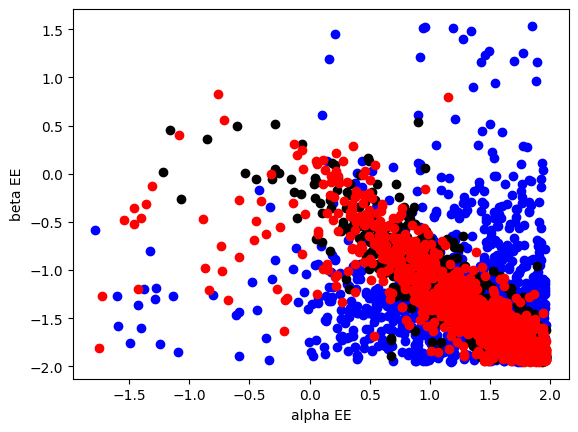

In [ ]:
a = np.load("npe_posterior_samples_1000.npy")
b = np.load("mf_npe_posterior_samples_[10000, 1000].npy")
c = np.load("mf_npe_posterior_samples_[100000, 1000].npy")
print(a.shape, b.shape, c.shape)

total = np.append(a, b, axis=0)
total = np.append(total, c, axis=0)
total = np.append(total, [[10.] for i in range(total.shape[0])], axis=1) #append the input rate to the thetas, here not random but 10Hz for all.
print(total.shape, total[0])

plt.scatter(total[:1000,2], total[:1000,3], color='blue')
plt.scatter(total[1000:2000,2], total[1000:2000,3], color='black')
plt.scatter(total[2000:,2], total[2000:,3], color='red')
plt.xlabel('alpha EE')
plt.ylabel('beta EE')
plt.show()

np.save("3000_samples_anonymous_10012025.npy", total)

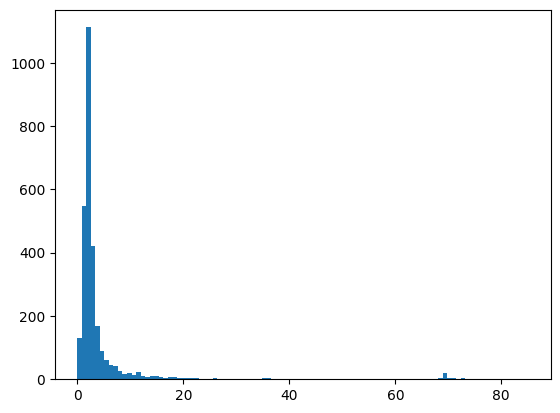

110 / 3000 sims blew up (so bad no data was generated)


In [ ]:
# what we get from the cluster + postprocessing (for all the samples)
data = np.load("bg_IF_EEEIIEII_6pPol_3000_samples_anonymous_10012025_metrics.npy")

plt.hist(data['rate'], bins=100); plt.show()
print(np.sum(data['rate'] != data['rate']),"/",len(data), "sims blew up (so bad no data was generated)")

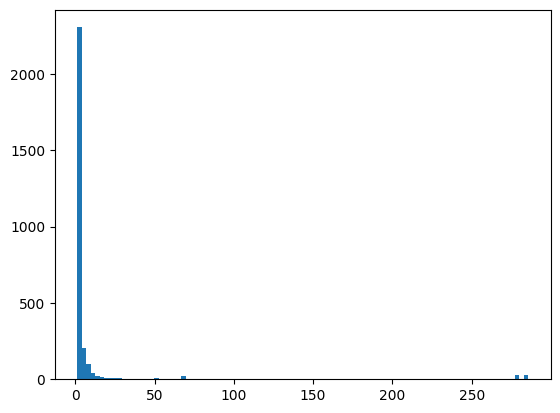

110 / 3000 sims blew up (so bad no data was generated)


In [ ]:
# what we get from the cluster + postprocessing (for all the samples)
data = np.load("bg_IF_EEEIIEII_6pPol_3000_samples_anonymous_10012025_metrics.npy")

plt.hist(data['rate_i'], bins=100); plt.show()
print(np.sum(data['rate_i'] != data['rate_i']),"/",len(data), "sims blew up (so bad no data was generated)")

In [9]:
# separating the big metric file into the 3 initial files
inds_a = []; inds_b = []; inds_c = []
for ind_small_file in range(len(a)):
    # first file:
    theta = a[ind_small_file]
    seed = hashlib.md5(str(np.append(theta, 10)).encode()).hexdigest() #how we associated every 25 dim theta (with input rate) to a single string, the seed/key
    ind_big_file = np.where(data['seed']==seed)[0][0] # the ind of the same seed (same theta) in the big file. didnt include checks if several identical seeds but highly unlikely
    inds_a.append(ind_big_file)

    # do the same for the other files
    theta = b[ind_small_file]
    seed = hashlib.md5(str(np.append(theta, 10)).encode()).hexdigest() #how we associated every 25 dim theta (with input rate) to a single string, the seed/key
    ind_big_file = np.where(data['seed']==seed)[0][0] # the ind of the same seed (same theta) in the big file. didnt include checks if several identical seeds but highly unlikely
    inds_b.append(ind_big_file)

    theta = c[ind_small_file]
    seed = hashlib.md5(str(np.append(theta, 10)).encode()).hexdigest() #how we associated every 25 dim theta (with input rate) to a single string, the seed/key
    ind_big_file = np.where(data['seed']==seed)[0][0] # the ind of the same seed (same theta) in the big file. didnt include checks if several identical seeds but highly unlikely
    inds_c.append(ind_big_file)

print(len(inds_a), len(inds_b), len(inds_c), inds_a)
# little check what we forgot no one along the way: inds_a inds_b inds_c should collectively have all indices 0 -> 2999: sum n(n+1)/2
print("check:", np.sum(inds_a)+np.sum(inds_b)+np.sum(inds_c), "=", int(2999*3000/2), "?" ) #seems we good
data_a = data[inds_a]
data_b = data[inds_b]
data_c = data[inds_c]

1000 1000 1000 [2665, 2661, 1847, 1916, 2329, 2798, 569, 2394, 284, 2792, 2468, 1366, 189, 1470, 2134, 1017, 2174, 2352, 300, 1744, 1489, 1909, 1520, 1333, 323, 185, 329, 2950, 727, 1022, 904, 2266, 2175, 269, 160, 2431, 609, 1645, 588, 2939, 704, 2992, 1900, 1146, 1006, 2955, 1136, 532, 635, 615, 1706, 186, 2892, 1795, 734, 1957, 330, 250, 589, 1478, 533, 2695, 2137, 498, 982, 2181, 1617, 735, 1269, 340, 1571, 1448, 2636, 2635, 2740, 2534, 967, 2114, 1993, 1511, 1563, 1060, 418, 2239, 1689, 2187, 2733, 1328, 2725, 2569, 2223, 807, 2598, 487, 567, 1820, 1903, 2899, 1212, 2301, 163, 2668, 1752, 1942, 748, 1211, 2287, 956, 1421, 2555, 1646, 206, 2572, 1235, 1684, 961, 1745, 1465, 1690, 738, 2801, 1391, 1418, 1969, 1794, 2883, 650, 2233, 1282, 1363, 593, 657, 61, 850, 2368, 2067, 995, 175, 789, 287, 1553, 241, 2221, 817, 2207, 841, 1846, 536, 1772, 2308, 2747, 2808, 1509, 2827, 2513, 928, 2578, 2715, 2277, 2275, 2478, 1311, 2860, 114, 195, 1972, 2720, 953, 263, 1609, 825, 1757, 49, 1160, 

In [13]:
# curious: who has the most stable rules
#aux functions
def apply_1_condition(dataset, condition):
    return(np.logical_and(condition[1] <= dataset[condition[0]], dataset[condition[0]] <= condition[2]))

def apply_n_conditions(dataset, conditions):
    n_conditions = len(conditions)
    cond = apply_1_condition(dataset, conditions[0])
    for i in range(1, n_conditions):
        cond = np.logical_and(cond, apply_1_condition(dataset, conditions[i]))
    return(cond)

cond_r = ("rate", 1, 50)
cond_cv = ("cv_isi", 0.7, 1000)
cond_sf = ("spatial_Fano", 0.5, 2.5)
cond_tf = ("temporal_Fano", 0.5, 2.5)
cond_ac = ("auto_cov", 0, 0.1)
cond_fft = ("fft", 0, 1)
cond_wb = ("w_blow", 0, 0.1)
cond_srt = ("std_rate_temporal", 0, 0.5)
cond_srs = ("std_rate_spatial", 0, 5)
cond_scv = ("std_cv", 0, 0.2)
cond_wc = ("w_creep", 0, 0.05)
cond_ri = ("rate_i", 1, 50)
cond_weef =("weef", 0 ,0.5)
cond_weif =("weif", 0 ,0.5)
cond_wief =("wief", 0 ,5)
cond_wiif =("wiif", 0 ,5)

cond_plausible = (cond_r,cond_ri,
            cond_wb,cond_wc,cond_weef,cond_weif, cond_wief, cond_wiif,
            cond_ac,cond_cv,cond_fft,cond_srt,cond_srs,cond_sf,cond_tf)
cond_plausible_a = apply_n_conditions(data_a, cond_plausible)
cond_plausible_b = apply_n_conditions(data_b, cond_plausible)
cond_plausible_c = apply_n_conditions(data_c, cond_plausible)
print("posterior a:", np.sum(cond_plausible_a), "posterior b:", np.sum(cond_plausible_b), "posterior c:", np.sum(cond_plausible_c), "are plausible (good) samples")



# This is what I fit my posteriors to
# 66,4 % is good, and % 94,2 or 95,6% are good predictions with multifidelity.
cond_rates_only = (cond_r,cond_ri)
cond_rates_only_a = apply_n_conditions(data_a, cond_rates_only)
cond_rates_only_b = apply_n_conditions(data_b, cond_rates_only)
cond_rates_only_c = apply_n_conditions(data_c, cond_rates_only)
print("posterior a:", np.sum(cond_rates_only_a), "posterior b:", np.sum(cond_rates_only_b), "posterior c:", np.sum(cond_rates_only_c), "have good rates (what I think you fit your posteriors)")

posterior a: 27 posterior b: 254 posterior c: 253 are plausible (good) samples
posterior a: 644 posterior b: 942 posterior c: 956 have good rates (what I think you fit your posteriors)


In [ ]:
# Plot initial samples, and the inferred ones

In [22]:
# Plot the posterior predictions on the samples
print(data_a['rate'])
# print(data_a['rate_i'])

[9.23730e+00 1.12616e+01 3.84030e+00 0.00000e+00 3.30520e+00 1.50550e+00
 8.84710e+00 1.48878e+01 4.12680e+00 2.52730e+00 2.98000e-02 2.07770e+00
 7.92390e+00 2.29269e+01 5.58525e+01 3.91304e+01 1.81080e+00 6.45910e+00
 7.52720e+00 4.64700e-01 9.91500e-01 2.48340e+00 1.99900e+00 7.30600e-01
 1.16000e+00 1.86338e+01 2.75480e+00 3.17000e-02 6.51570e+00         nan
 1.58738e+01 6.80369e+01 3.20300e+00         nan 2.12160e+00 2.33150e+00
 1.01400e+00 3.80630e+00 8.40500e-01 6.55100e-01         nan         nan
 1.89630e+00 7.18510e+00 3.11090e+00         nan 3.79160e+00 2.57300e+00
 3.34745e+01 6.59700e-01 1.15136e+01 1.20390e+00 1.99830e+00 0.00000e+00
 3.90530e+00 6.68870e+00 5.71900e+00 7.32200e-01 1.30870e+00 9.59950e+00
 1.60264e+01 4.27510e+00 4.16590e+00 3.21940e+00 1.70250e+00 5.19700e+00
 3.10720e+00 1.31740e+00 1.87193e+01 2.35180e+00 2.01300e+00 1.27860e+00
 8.19510e+00 7.27504e+01 2.05193e+01 4.12550e+00 7.59590e+00 6.41810e+00
 1.06390e+00 3.62599e+01 8.48170e+00 7.13720e+00 1.

In [49]:
import torch


rates_exc = data_a['rate']
rates_inh = data_a['rate_i']

rates_exc = torch.tensor(np.array(rates_exc), dtype=torch.float32).unsqueeze(1)
rates_inh = torch.tensor(np.array(rates_inh), dtype=torch.float32).unsqueeze(1)

theta = torch.tensor(np.array(data_a['theta']), dtype=torch.float32)


tpreEE = theta[:, 0]
tpostEE = theta[:, 1]
alphaEE = theta[:, 2]
betaEE = theta[:, 3]
gammaEE = theta[:, 4]
kappaEE = theta[:, 5]

tpreEI = theta[:, 6]
tpostEI = theta[:, 7]
alphaEI = theta[:, 8]
betaEI = theta[:, 9]
gammaEI = theta[:, 10]
kappaEI = theta[:, 11]

lambdaEE = kappaEE * tpostEE + gammaEE * tpreEE
lambdaEI = kappaEI * tpostEI + gammaEI * tpreEI

In [ ]:
# rates_exc = data_a['rate']
# rates_inh = data_a['rate_i']


In [54]:
# One true_x, one true_param set

array([9.2373], dtype=float32)

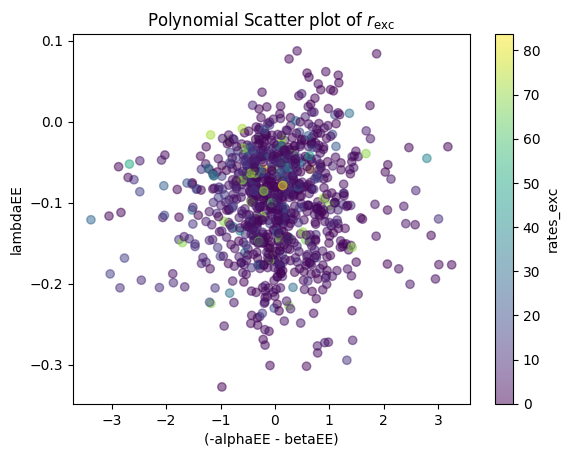

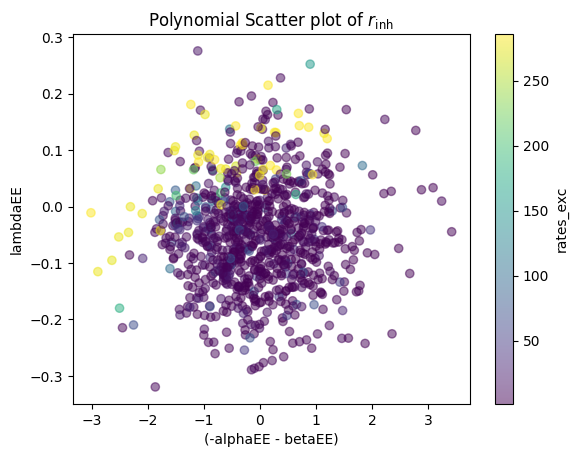

In [57]:
def plot_scatter(alpha, beta, lambda_rule, rates, type_rule):
        # EE and EI rules
        plt.figure()
        plt.scatter((-alpha - beta).numpy(), lambda_rule.numpy(), c=rates.numpy(), alpha=0.5, cmap='viridis')
        plt.xlabel('(-alphaEE - betaEE)')
        plt.ylabel('lambdaEE')
        plt.title(f'Polynomial Scatter plot of {type_rule}')
        plt.colorbar(label='rates_exc')
        plt.show()

plot_scatter(alphaEE, betaEE, lambdaEE, rates_exc, "$r_{\mathrm{exc}}$")
# Plot inhibitory rules
plot_scatter(alphaEI, betaEI, lambdaEI, rates_inh, "$r_{\mathrm{inh}}$") 